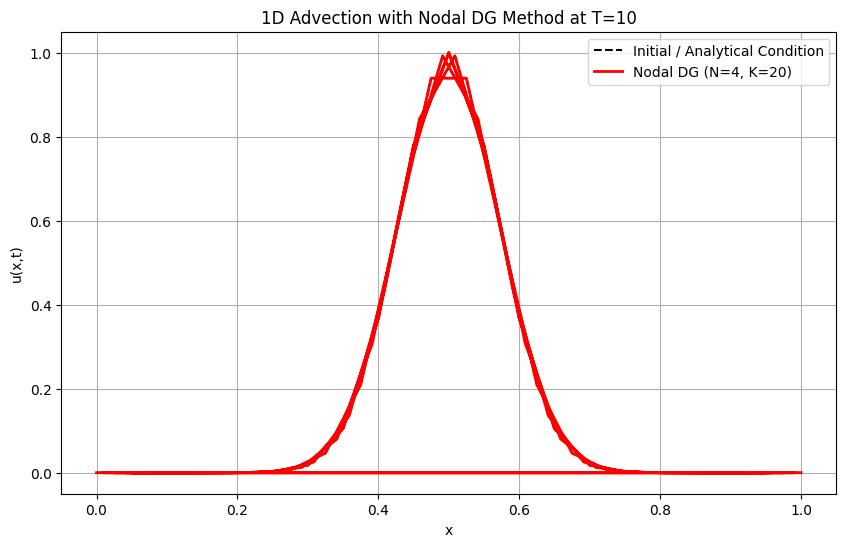

In [1]:
import numpy as np
import scipy.special
import matplotlib.pyplot as plt

def solve_advection_dg(N, K, c=1.0, T=1.0, cfl=0.3):
    """
    Solves the 1D Advection Equation using Nodal Discontinuous Galerkin (DG).
    
    Parameters:
    -----------
    N : int
        Polynomial order inside each element (N+1 nodes per element).
    K : int
        Number of elements.
    c : float
        Advection speed.
    T : float
        Final simulation time.
    cfl : float
        CFL safety factor for time-step determination.
    """
    # -----------------------------------------------------------------
    # 1. Mesh and Geometry Setup
    # -----------------------------------------------------------------
    xmin, xmax = 0.0, 1.0
    x_edges = np.linspace(xmin, xmax, K + 1)
    dx = (xmax - xmin) / K
    J = dx / 2.0  # Constant Jacobian for uniform grid
    
    u_history = []
    
    # -----------------------------------------------------------------
    # 2. Compute LGL Nodes on Reference Element [-1, 1]
    # -----------------------------------------------------------------
    if N == 1:
        r = np.array([-1.0, 1.0])
    else:
        # Internal LGL nodes correspond to roots of Jacobi polynomial P^(1,1)_{N-1}
        internal_nodes, _ = scipy.special.roots_jacobi(N - 1, 1, 1)
        r = np.concatenate([[-1.0], internal_nodes, [1.0]])
        
    # -----------------------------------------------------------------
    # 3. Construct Operators (Vandermonde, Differentiation, Lift)
    # -----------------------------------------------------------------
    V = np.zeros((N + 1, N + 1))
    Vr = np.zeros((N + 1, N + 1))
    
    for j in range(N + 1):
        # Orthonormal Legendre basis evaluation
        c_norm = np.sqrt((2 * j + 1) / 2)
        V[:, j] = c_norm * scipy.special.eval_legendre(j, r)
        
        # Stable derivative evaluation using polynomial recurrence relations
        dy = np.zeros_like(r)
        for k in range(j - 1, -1, -2):
            dy += (2 * k + 1) * scipy.special.eval_legendre(k, r)
        Vr[:, j] = c_norm * dy
        
    invV = np.linalg.inv(V)
    D = Vr @ invV          # Nodal differentiation matrix
    M_inv = V @ V.T        # Inverse Mass matrix (using orthonormal property V * V^T)
    
    # Lift matrix maps boundary flux jumps to the volume nodes
    LIFT = np.zeros((N + 1, 2))
    LIFT[:, 0] = M_inv[:, 0]  # Left boundary contribution
    LIFT[:, 1] = M_inv[:, N]  # Right boundary contribution
    
    # -----------------------------------------------------------------
    # 4. Map Coordinates to Global Domain
    # -----------------------------------------------------------------
    # Shape of x: (N + 1, K) -> Rows: local nodes, Columns: elements
    x = np.zeros((N + 1, K))
    for k in range(K):
        x[:, k] = x_edges[k] + (r + 1.0) * J
        
    # -----------------------------------------------------------------
    # 5. Initial Condition (Gaussian Pulse + Periodic boundaries)
    # -----------------------------------------------------------------
    u0 = np.exp(-100.0 * (x - 0.5)**2)
    u = u0.copy()
    
    # -----------------------------------------------------------------
    # 6. Time Integration Configuration
    # -----------------------------------------------------------------
    # Stable dt depends on the minimum distance between adjacent LGL nodes
    r_min = np.min(np.diff(r))
    dt = cfl * (J * r_min) / abs(c)
    n_steps = int(np.ceil(T / dt))
    dt = T / n_steps  # Adjust dt to match T exactly
    
    # -----------------------------------------------------------------
    # 7. Core RHS Evaluation Function
    # -----------------------------------------------------------------
    def compute_rhs(u_local):
        # Volumetric derivative contribution
        rhs = -(c / J) * (D @ u_local)
        
        # Interface terms via general upwind formulation based on normal vectors
        # Periodic boundaries are enforced via np.roll
        
        # Left boundary of each element (normal vector n = -1)
        u_left_ext = np.roll(u_local[N, :], 1)   # Right boundary value of previous element
        flux_L = 0.5 * (-c - abs(c)) * (u_local[0, :] - u_left_ext)
        
        # Right boundary of each element (normal vector n = +1)
        u_right_ext = np.roll(u_local[0, :], -1) # Left boundary value of next element
        flux_R = 0.5 * (c - abs(c)) * (u_local[N, :] - u_right_ext)
        
        # Add surface numerical flux corrections using the Lift operator
        rhs += (1.0 / J) * (LIFT[:, 0:1] * flux_L + LIFT[:, 1:2] * flux_R)
        return rhs

    # -----------------------------------------------------------------
    # 8. Time-Stepping (RK4)
    # -----------------------------------------------------------------
    for step in range(n_steps):
        k1 = compute_rhs(u)
        k2 = compute_rhs(u + 0.5 * dt * k1)
        k3 = compute_rhs(u + 0.5 * dt * k2)
        k4 = compute_rhs(u + dt * k3)
        u += (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        u_history.append(u)
        
    return x, u0, u, u_history

# --- Execution and Post-Processing ---
if __name__ == "__main__":
    # Parameters: N = polynomial order, K = number of elements
    N_poly = 4
    K_elements = 20
    c_speed = 1.0
    T_final = 10  # Exactly 1 full period for domain [0, 1] if c=1
    
    x, u_init, u_final, u_history = solve_advection_dg(N=N_poly, K=K_elements, c=c_speed, T=T_final)
    
    # Flatten arrays for easy plotting across element discontinuities
    plt.figure(figsize=(10, 6))
    plt.plot(x.flatten(), u_init.flatten(), 'k--', label='Initial / Analytical Condition')
    plt.plot(x.flatten(), u_final.flatten(), 'r-', linewidth=2, label=f'Nodal DG (N={N_poly}, K={K_elements})')
    
    plt.title(f"1D Advection with Nodal DG Method at T={T_final}")
    plt.xlabel("x")
    plt.ylabel("u(x,t)")
    plt.grid(True)
    plt.legend()
    plt.show()

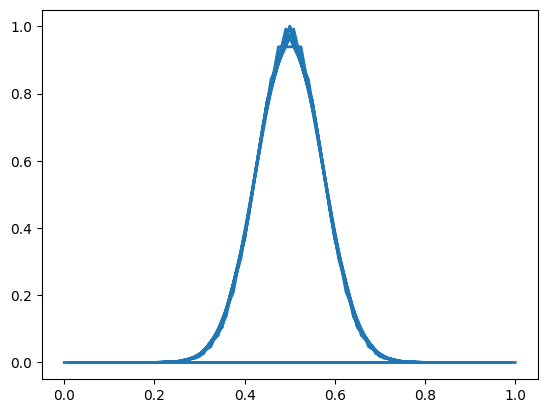

In [6]:
plt.plot(x.flatten(), u_history[10].flatten(), linewidth=2, label=f'Nodal DG (N={N_poly}, K={K_elements})')

In [3]:
u_history[0].shape

(5, 20)

In [11]:
u_history[10][4,10]

np.float64(0.7787975161995969)

In [4]:
x.shape

(5, 20)

In [5]:
x

array([[0.        , 0.05      , 0.1       , 0.15      , 0.2       ,
        0.25      , 0.3       , 0.35      , 0.4       , 0.45      ,
        0.5       , 0.55      , 0.6       , 0.65      , 0.7       ,
        0.75      , 0.8       , 0.85      , 0.9       , 0.95      ],
       [0.00863366, 0.05863366, 0.10863366, 0.15863366, 0.20863366,
        0.25863366, 0.30863366, 0.35863366, 0.40863366, 0.45863366,
        0.50863366, 0.55863366, 0.60863366, 0.65863366, 0.70863366,
        0.75863366, 0.80863366, 0.85863366, 0.90863366, 0.95863366],
       [0.025     , 0.075     , 0.125     , 0.175     , 0.225     ,
        0.275     , 0.325     , 0.375     , 0.425     , 0.475     ,
        0.525     , 0.575     , 0.625     , 0.675     , 0.725     ,
        0.775     , 0.825     , 0.875     , 0.925     , 0.975     ],
       [0.04136634, 0.09136634, 0.14136634, 0.19136634, 0.24136634,
        0.29136634, 0.34136634, 0.39136634, 0.44136634, 0.49136634,
        0.54136634, 0.59136634, 0.64136634, 0